In [17]:
import numpy as np 
import pandas as pd 

from ydata_profiling import ProfileReport
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub

/kaggle/input/datasets/flaviamonique/dados-tempo-resposta-cpu/dados_tempo_resposta_cpu.csv


# Leindo a Base de dados

In [18]:
dados = pd.read_csv('/kaggle/input/datasets/flaviamonique/dados-tempo-resposta-cpu/dados_tempo_resposta_cpu.csv', sep=';')
dados

,Tempo de Resposta (ms),Carga de CPU
0,50,25
1,62,31
2,48,22
3,75,45
4,88,55
5,55,28
6,95,60
7,110,72
8,68,39
9,82,50


# Ajuste da Base

In [19]:
dados.columns

Index(['Tempo de Resposta (ms)', 'Carga de CPU '], dtype='object')

In [20]:
dados = dados.rename(columns={'Carga de CPU ': 'carga_cpu','Tempo de Resposta (ms)': 'tempo_resposta'})

# Análises

* Tempo_resposta:
    * Média: 79.733333
    * Mediana: 78.0
    * Quartis:
    |Quartil| valor |
    | ---- | ---- |
    | 25% |	65.000000 |
    | 50% |	78.000000 |
    | 75% |	92.500000 |
    * desvio padrão:21.815678


* Carga_cpu:
    * Média: 47.933333
    * Mediana: 48.0
    * Quartis:
    |Quartil| valor |
    | ---- | ---- |
    | 25% |	35.000000 |
    | 50% |	48.000000 |
    | 75% |	59.000000 |
    * desvio padrão: 17.359504

# Correlação das váriáveis
0.9969449635801236

|---|	tempo_resposta	|carga_cpu | 
|--|--|--|
|tempo_resposta|	1.000000	| 0.996945|
|carga_cpu	|0.996945 | 1.000000 |

# Covariancia 

COV. 377.55238095238093

| --- | Carga_cpu | tempo_resposta |
|--|--|--|
| carga_cpu	| 301.352381| 	377.552381 |
| tempo_resposta| 	377.552381	| 475.923810|



# Inferência

A análise mostra uma corelação positiva forte entre as duas variáveis. Sendo essa correlação de 0.996 entende-se que os valores maiores em relação ao uso da CPU se relacionam aos valores maiores de tempo de resposta.

In [21]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   tempo_resposta  15 non-null     int64
 1   carga_cpu       15 non-null     int64
dtypes: int64(2)
memory usage: 372.0 bytes


In [22]:
dados.describe()

,tempo_resposta,carga_cpu
count,15.000000,15.000000
mean,79.733333,47.933333
std,21.815678,17.359504
min,48.000000,22.000000
25%,65.000000,35.000000
50%,78.000000,48.000000
75%,92.500000,59.000000
max,120.000000,80.000000


In [23]:
mediana_tempo_resposta = dados['tempo_resposta'].median()
mediana_tempo_resposta

78.0

In [24]:
mediana_carga_cpu = dados['carga_cpu'].median()
mediana_carga_cpu

48.0

In [25]:
variancia_tempo_de_resposta= np.var(dados['tempo_resposta']) 
variancia_tempo_de_resposta

444.1955555555556

In [26]:
variancia_carga_de_CPU= np.var(dados['carga_cpu']) 
variancia_carga_de_CPU

281.2622222222223

In [27]:
ProfileReport(dados)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 2/2 [00:00<00:00, 15827.56it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

# Correlação

In [28]:
dados[['tempo_resposta', 'carga_cpu']].corr()

,tempo_resposta,carga_cpu
tempo_resposta,1.000000,0.996945
carga_cpu,0.996945,1.000000


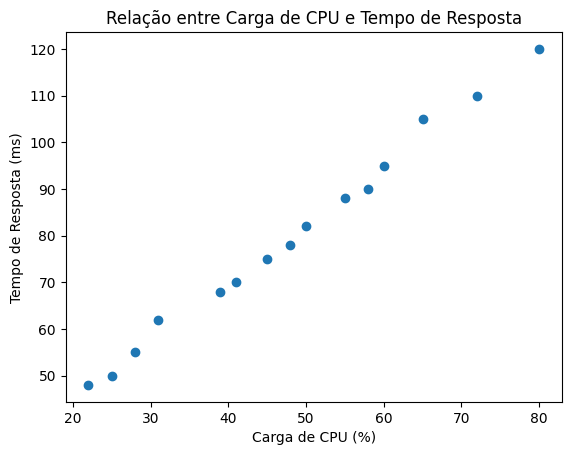

In [29]:
import matplotlib.pyplot as plt

plt.scatter(dados['carga_cpu'], dados['tempo_resposta'])

plt.xlabel('Carga de CPU (%)')
plt.ylabel('Tempo de Resposta (ms)')
plt.title('Relação entre Carga de CPU e Tempo de Resposta')

plt.show()

In [30]:
dados[['tempo_resposta', 'carga_cpu']].corr()

,tempo_resposta,carga_cpu
tempo_resposta,1.000000,0.996945
carga_cpu,0.996945,1.000000


# Covariância

In [31]:
covariancia = dados['carga_cpu'].cov(dados['tempo_resposta'])

print(covariancia)

377.55238095238093


In [32]:
dados[['carga_cpu', 'tempo_resposta']].cov()

,carga_cpu,tempo_resposta
carga_cpu,301.352381,377.552381
tempo_resposta,377.552381,475.923810
